## Quasi Periodic Eruptions – Plots

#### Define Reader Functions

In [33]:
from svgpathtools import svg2paths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_exact_curves(svg_file_path):
    paths, attributes = svg2paths(svg_file_path)
    
    red_identifiers = ['#ff0000', 'rgb(255,0,0)', 'rgb(255, 0, 0)']
    blue_identifiers = ['#0000ff', 'rgb(0,0,255)', 'rgb(0, 0, 255)']
    
    red_points = []
    blue_points = []
    
    for path, attr in zip(paths, attributes):
        
        style_str = attr.get('style', '').lower()
        stroke_str = attr.get('stroke', '').lower()
        fill_str = attr.get('fill', '').lower()
        combined_attr = f"{style_str} {stroke_str} {fill_str}"
        
        is_red = any(color in combined_attr for color in red_identifiers)
        is_blue = any(color in combined_attr for color in blue_identifiers)
        
        if is_red or is_blue:
            points = []
            for segment in path:
                points.append((segment.start.real, segment.start.imag))
            
            if path:
                points.append((path[-1].end.real, path[-1].end.imag))
                
            if is_red:
                red_points.extend(points)
            if is_blue:
                blue_points.extend(points)

    def clean_data(point_list):
        if not point_list:
            return pd.DataFrame(columns=['x_svg', 'y_svg'])
        
        unique_points = list(dict.fromkeys(point_list))
        df = pd.DataFrame(unique_points, columns=['x_svg', 'y_svg'])
        
        df['y_svg'] = -df['y_svg']
        return df

    df_red = clean_data(red_points)
    df_blue = clean_data(blue_points)
    
    return df_red, df_blue

def extract_axis_ticks(svg_file_path, max_tick_length=15):
    paths, attributes = svg2paths(svg_file_path)
    
    x_tick_coords = [] # Vertical lines indicating X positions
    y_tick_coords = [] # Horizontal lines indicating Y positions
    
    for path in paths:
        for segment in path:
            # Get start and end points
            x1, y1 = segment.start.real, segment.start.imag
            x2, y2 = segment.end.real, segment.end.imag
            
            dx = abs(x1 - x2)
            dy = abs(y1 - y2)
            length = (dx**2 + dy**2)**0.5
            
            # 1. Filter by length to ignore axes or data curves
            if 0 < length <= max_tick_length:
                
                # 2. Identify X-ticks: Vertical lines (constant x)
                # We extract the x-coordinate where the tick occurs
                if dx < 0.01: # Tolerance for near-perfect vertical
                    x_tick_coords.append(x1)
                
                # 3. Identify Y-ticks: Horizontal lines (constant y)
                # We extract the y-coordinate where the tick occurs
                elif dy < 0.01: # Tolerance for near-perfect horizontal
                    y_tick_coords.append(y1)

    def clean_ticks(coords, label):
        if not coords:
            return pd.DataFrame(columns=[label])
        
        # Sort and remove duplicates (ticks often have overlapping segments)
        df = pd.DataFrame(sorted(list(set(coords))), columns=[label])
        
        # Invert Y if you want to match your curve cleaning logic
        if label == 'y_svg':
            df['y_svg'] = -df['y_svg']
            
        return df

    df_x_ticks = clean_ticks(x_tick_coords, 'x_svg')
    df_y_ticks = clean_ticks(y_tick_coords, 'y_svg')
    
    return df_x_ticks, df_y_ticks

def extract_major_ticks(svg_file_path):
    paths, attributes = svg2paths(svg_file_path)
    
    # Storage for (coordinate, length) tuples
    x_candidates = [] # [(x_val, length), ...]
    y_candidates = [] # [(y_val, length), ...]
    
    for path in paths:
        for segment in path:
            x1, y1 = segment.start.real, segment.start.imag
            x2, y2 = segment.end.real, segment.end.imag
            
            dx = abs(x1 - x2)
            dy = abs(y1 - y2)
            length = (dx**2 + dy**2)**0.5
            
            # Identify Vertical segments (X-axis ticks)
            if dx < 0.01 and length > 0.1:
                x_candidates.append((x1, length))
            
            # Identify Horizontal segments (Y-axis ticks)
            elif dy < 0.01 and length > 0.1:
                y_candidates.append((y1, length))

    def filter_major(candidates):
        if not candidates:
            return []
        
        # Find the maximum length in this set of candidates
        max_len = max(c[1] for c in candidates)
        
        # Filter: Only keep segments that match the maximum length
        # We use a small tolerance (0.1) in case of rendering offsets
        major_coords = [c[0] for c in candidates if abs(c[1] - max_len) < 0.1]
        
        # Deduplicate and sort
        return sorted(list(set(major_coords)))

    def clean_data(coords, label):
        df = pd.DataFrame(coords, columns=[label])
        if label == 'y_svg':
            df['y_svg'] = -df['y_svg']
        return df

    # Process and filter
    major_x = filter_major(x_candidates)
    major_y = filter_major(y_candidates)
    
    return clean_data(major_x, 'x_svg'), clean_data(major_y, 'y_svg')

#### Read Vector Files

found 635 red points and 138 blue points


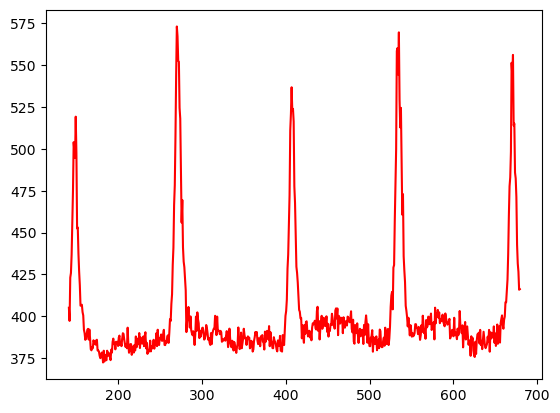

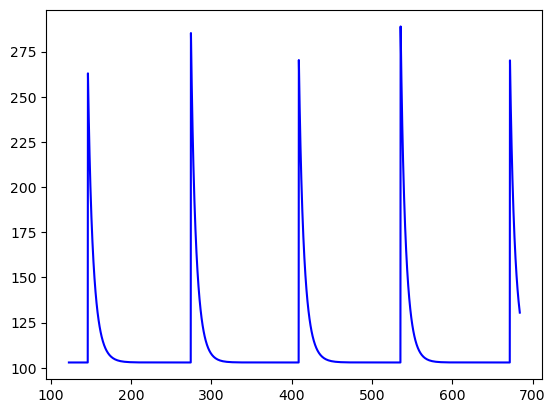

In [65]:
df_red, df_blue = extract_exact_curves('content/g2865_test.svg')
print(f"found {len(df_red)} red points and {len(df_blue)} blue points")

xr1 = np.array(df_red['x_svg'])
yr1 = -np.array(df_red['y_svg'])
plt.plot(xr1, yr1, 'r')
plt.show()
plt.close()

xb1 = np.array(df_blue['x_svg'])
yb1 = -np.array(df_blue['y_svg'])
plt.plot(xb1, yb1, 'b')
plt.show()
plt.close()

found 387 red points and 215 blue points


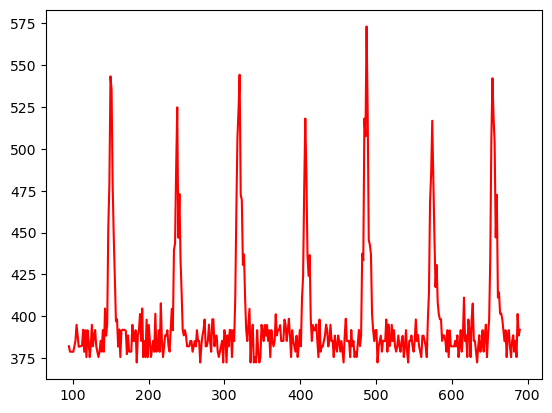

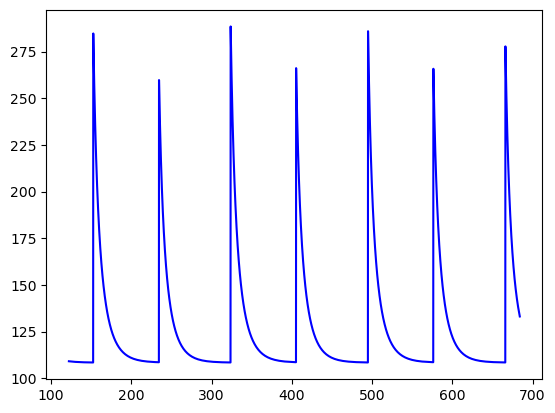

In [66]:
df_red, df_blue = extract_exact_curves('content/g3684_test.svg')
print(f"found {len(df_red)} red points and {len(df_blue)} blue points")

xr2 = np.array(df_red['x_svg'])[:-8]
yr2 = -np.array(df_red['y_svg'])[:-8]
plt.plot(xr2, yr2, 'r')
plt.show()
plt.close()

xb2 = np.array(df_blue['x_svg'])
yb2 = -np.array(df_blue['y_svg'])
plt.plot(xb2, yb2, 'b')
plt.show()
plt.close()

found 465 red points and 379 blue points


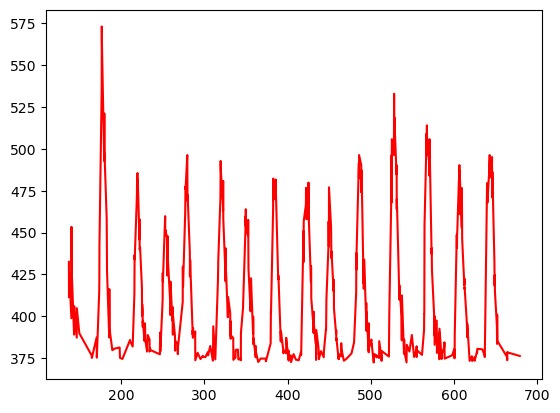

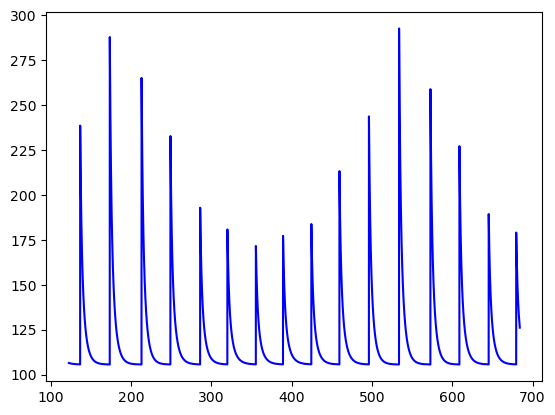

In [67]:
df_red, df_blue = extract_exact_curves('content/g4469_test.svg')
print(f"found {len(df_red)} red points and {len(df_blue)} blue points")

xr3 = np.array(df_red['x_svg'])[:-8]
yr3 = -np.array(df_red['y_svg'])[:-8]
plt.plot(xr3, yr3, 'r')
plt.show()
plt.close()

xb3 = np.array(df_blue['x_svg'])
yb3 = -np.array(df_blue['y_svg'])
plt.plot(xb3, yb3, 'b')
plt.show()
plt.close()

found 466 red points and 237 blue points


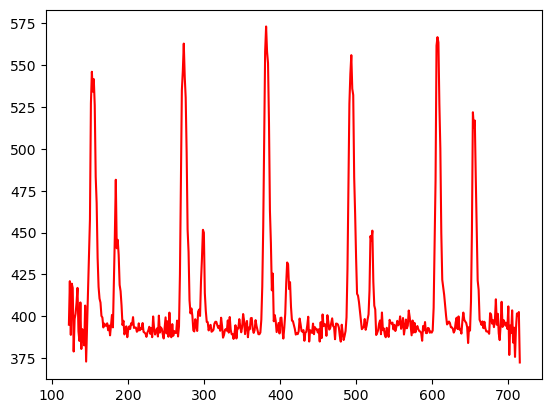

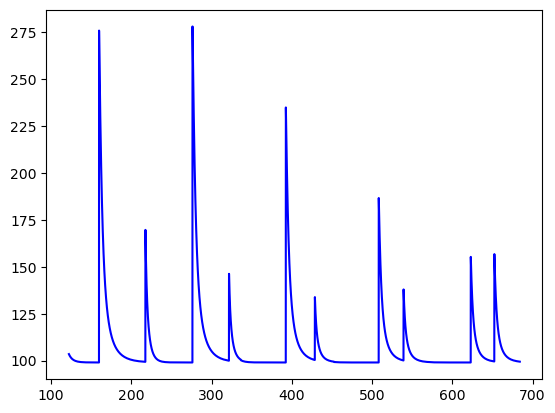

In [68]:
df_red, df_blue = extract_exact_curves('content/g5245_test.svg')
print(f"found {len(df_red)} red points and {len(df_blue)} blue points")

xr4 = np.array(df_red['x_svg'])[:-8]
yr4 = -np.array(df_red['y_svg'])[:-8]
plt.plot(xr4, yr4, 'r')
plt.show()
plt.close()

xb4 = np.array(df_blue['x_svg'])
yb4 = -np.array(df_blue['y_svg'])
plt.plot(xb4, yb4, 'b')
plt.show()
plt.close()

#### Scale Axes

found 19 xticks and 18 yticks


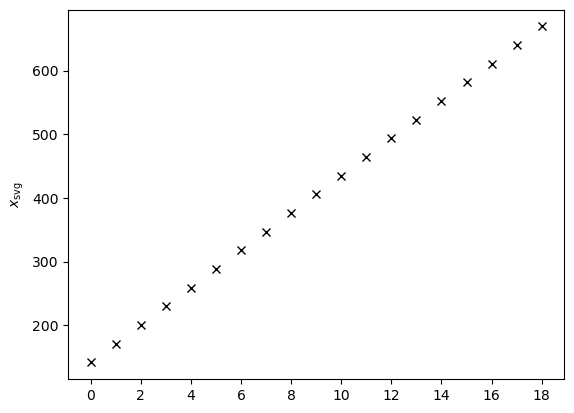

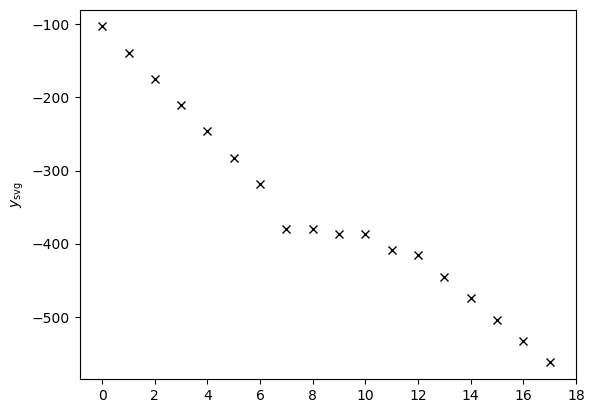

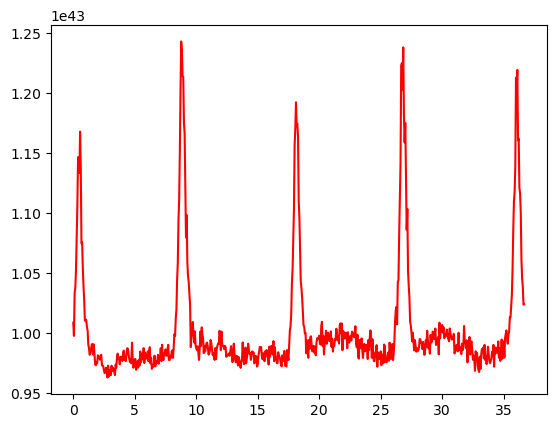

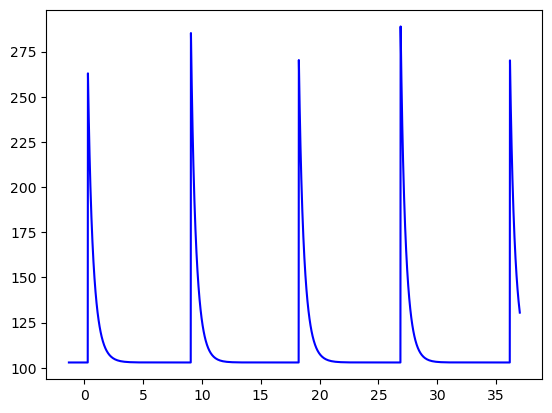

In [71]:
df_xticks, df_yticks = extract_axis_ticks('content/g2865_test.svg')
print(f"found {len(df_xticks)} xticks and {len(df_yticks)} yticks")

xt = np.array(df_xticks['x_svg'])
yt = np.array(df_yticks['y_svg'])

plt.plot(xt, 'kx')
plt.xticks(np.arange(0, len(xt) + 1, 2))
plt.ylabel(r'$x_\text{svg}$')
plt.show()
plt.close()

plt.plot(yt, 'kx')
plt.xticks(np.arange(0, len(yt) + 1, 2))
plt.ylabel(r'$y_\text{svg}$')
plt.show()
plt.close()

xt1 = xt[0]
xt2 = xt[5]

rxt1 = 0.0
rxt2 = 10.0

xrc1 = rxt1 + (xr1 - xt1) * (rxt1 - rxt2) / (xt1 - xt2)
xbc1 = rxt1 + (xb1 - xt1) * (rxt1 - rxt2) / (xt1 - xt2)

yt1 = yt[2]
yt2 = yt[6]

ryt1 = 2e42
ryt2 = 0e42

yrc1 = ryt1 + (yr1 - yt1) * (ryt1 - ryt2) / (yt1 - yt2)

plt.plot(xrc1, yrc1, 'r')
plt.show()
plt.close()

plt.plot(xbc1, yb1, 'b')
plt.show()
plt.close()